# Agentic AI Fundamentals

## Notebook 07: LangGraph Fundamentals and Stateful Agents

Our previous agent loop stored control flow inside one Python function. That approach is readable for a small system, but branching, checkpointing, human approval, and recovery become harder to manage as the application grows.

LangGraph represents the same runtime as a graph. Nodes perform work, shared state carries information between nodes, edges define valid transitions, and conditional edges choose the next node at runtime. We will first build a deterministic graph, then reconstruct the Gemini tool-using agent as a stateful graph.

## Learning objectives

By the end of this notebook, you should be able to:

- define graph state with `TypedDict`;
- implement nodes as state-to-update functions;
- connect nodes with normal and conditional edges;
- compile and invoke a `StateGraph`;
- express a model → tools → model loop as a graph;
- add an in-memory checkpointer and thread ID; and
- inspect final state and execution traces.

The notebook is self-contained for Colab and does not require external Python files.

## 1. Install dependencies and configure the API

The deterministic graph works without Gemini, but the complete agent section requires `GEMINI_API_KEY` in Colab Secrets.

In [2]:
%pip install -q -U "langgraph>=1.0,<2" "google-genai>=1.0.0" "pydantic>=2.7,<3"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.2/250.2 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.5/262.5 kB 19.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.58.1 which is incompatible.


In [3]:
import os


def load_gemini_api_key() -> str:
    try:
        from google.colab import userdata

        api_key = userdata.get("GEMINI_API_KEY")
    except (ImportError, KeyError):
        api_key = os.getenv("GEMINI_API_KEY")

    if not api_key:
        raise RuntimeError("Add GEMINI_API_KEY to Colab Secrets.")

    return api_key


GEMINI_API_KEY = load_gemini_api_key()

In [4]:
import json
import re
from dataclasses import dataclass
from typing import Any, Callable, Literal, TypedDict

from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from pydantic import BaseModel, ConfigDict, Field, ValidationError


MODEL_NAME = "gemini-3.8-flash"
print("Configured model:", MODEL_NAME)

Configured model: gemini-3.8-flash


In [5]:
from google import genai


client = genai.Client(api_key=GEMINI_API_KEY)
print("Gemini client initialized.")

Gemini client initialized.


## 2. The four graph concepts

A LangGraph application begins with four pieces:

- **State:** the shared data available to nodes.
- **Node:** a function that reads state and returns a partial state update.
- **Edge:** an allowed transition between nodes.
- **Router:** a function used by a conditional edge to select the next transition.

`START` and `END` are special graph boundaries. They are not application nodes and do not contain business logic.

## 3. Build a deterministic graph first

This graph repeatedly increments a counter until a target is reached. Although the task is simple, it demonstrates the same cycle used by an agent: perform work, inspect updated state, and either continue or stop.

In [6]:
class CounterState(TypedDict):
    count: int
    target: int
    trace: list[str]


def increment_node(state: CounterState) -> dict[str, Any]:
    next_count = state["count"] + 1
    next_trace = state["trace"] + [f"Incremented to {next_count}"]

    return {
        "count": next_count,
        "trace": next_trace,
    }


def route_counter(state: CounterState) -> Literal["increment", "finish"]:
    if state["count"] < state["target"]:
        return "increment"
    return "finish"

Nodes return only the fields they update. Avoid mutating the input state directly; returning explicit updates makes transitions easier to reason about and works better with checkpointing and reducers.

In [7]:
counter_builder = StateGraph(CounterState)
counter_builder.add_node("increment", increment_node)

counter_builder.add_edge(START, "increment")
counter_builder.add_conditional_edges(
    "increment",
    route_counter,
    {
        "increment": "increment",
        "finish": END,
    },
)

counter_graph = counter_builder.compile()

counter_result = counter_graph.invoke(
    {
        "count": 0,
        "target": 3,
        "trace": [],
    }
)

print(counter_result)

{'count': 3, 'target': 3, 'trace': ['Incremented to 1', 'Incremented to 2', 'Incremented to 3']}


The graph executed the same node three times. The conditional edge examined the updated count after each execution and selected either the self-loop or `END`.

## 4. Inspect the graph structure

LangGraph can render its topology as Mermaid syntax. Colab may render the diagram directly through IPython, but the text is also useful in documentation.

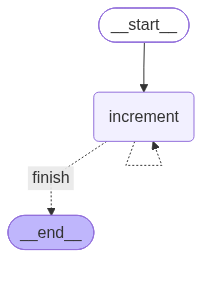

In [19]:
from IPython.display import Image, display

display(
    Image(
        counter_graph.get_graph().draw_mermaid_png()
    )
)

The topology tells us which transitions are possible. It does not show which route a particular run took; that information belongs in the execution trace or checkpoint history.

## 5. Define tools for the real graph

The agent graph will use multiplication and local course-note retrieval. We repeat the compact registry implementation so the notebook remains independently runnable.

In [9]:
def multiply(first_number: float, second_number: float) -> float:
    return first_number * second_number


COURSE_NOTES = {
    "langgraph": (
        "LangGraph represents stateful workflows with nodes, edges, "
        "conditional routing, and optional checkpointing."
    ),
    "node": (
        "A node reads graph state, performs work, and returns a partial update."
    ),
    "checkpoint": (
        "A checkpoint is a snapshot of graph state associated with a thread."
    ),
}


def search_course_notes(query: str, max_results: int = 2) -> list[dict[str, str]]:
    query_tokens = set(re.findall(r"[a-z0-9]+", query.casefold()))
    matches = []

    for topic, text in COURSE_NOTES.items():
        tokens = set(re.findall(r"[a-z0-9]+", f"{topic} {text}".casefold()))
        score = len(query_tokens & tokens)
        if score:
            matches.append((score, topic, text))

    matches.sort(reverse=True)
    return [
        {"topic": topic, "text": text}
        for _, topic, text in matches[:max_results]
    ]


class MultiplyArguments(BaseModel):
    model_config = ConfigDict(extra="forbid")
    first_number: float
    second_number: float


class SearchArguments(BaseModel):
    model_config = ConfigDict(extra="forbid")
    query: str = Field(min_length=3, max_length=300)
    max_results: int = Field(default=2, ge=1, le=3)

In [10]:
@dataclass(frozen=True)
class Tool:
    name: str
    description: str
    arguments_model: type[BaseModel]
    function: Callable[..., Any]

    def schema(self) -> dict[str, Any]:
        return {
            "type": "function",
            "name": self.name,
            "description": self.description,
            "parameters": self.arguments_model.model_json_schema(),
        }

    def execute(self, arguments: dict[str, Any]) -> Any:
        validated = self.arguments_model.model_validate(arguments)
        return self.function(**validated.model_dump())


class ToolRegistry:
    def __init__(self, tools: list[Tool]) -> None:
        self.tools = {tool.name: tool for tool in tools}
        if len(self.tools) != len(tools):
            raise ValueError("Tool names must be unique")

    def schemas(self) -> list[dict[str, Any]]:
        return [tool.schema() for tool in self.tools.values()]

    def execute(self, name: str, arguments: dict[str, Any]) -> dict[str, Any]:
        tool = self.tools.get(name)
        if tool is None:
            return {"success": False, "error": f"Unknown tool: {name}"}

        try:
            return {"success": True, "result": tool.execute(arguments)}
        except ValidationError as error:
            return {
                "success": False,
                "error_type": "invalid_arguments",
                "error": error.errors(),
            }
        except Exception as error:
            return {
                "success": False,
                "error_type": "execution_error",
                "error": f"{type(error).__name__}: {error}",
            }


registry = ToolRegistry(
    [
        Tool("multiply", "Multiply two numbers exactly.", MultiplyArguments, multiply),
        Tool(
            "search_course_notes",
            "Search local notes for LangGraph-specific definitions.",
            SearchArguments,
            search_course_notes,
        ),
    ]
)
gemini_tools = registry.schemas()

## 6. Design the agent graph state

The state includes user input, provider continuity, pending function calls, results for the next model turn, the final answer, counters, status, and a trace. Keeping these fields explicit makes every transition inspectable.

In [11]:
class AgentGraphState(TypedDict):
    user_message: str
    interaction_id: str | None
    pending_calls: list[dict[str, Any]]
    function_results: list[dict[str, Any]]
    answer: str | None
    status: str
    model_turns: int
    max_model_turns: int
    trace: list[dict[str, Any]]

## 7. Implement the model node

The node makes either an initial Gemini request or a continuation request containing tool results. It then converts provider-specific function-call objects into plain dictionaries stored in graph state.

In [12]:
def call_model_node(state: AgentGraphState) -> dict[str, Any]:
    next_turn = state["model_turns"] + 1

    if state["interaction_id"] is None:
        interaction = client.interactions.create(
            model=MODEL_NAME,
            input=state["user_message"],
            tools=gemini_tools,
        )
    else:
        interaction = client.interactions.create(
            model=MODEL_NAME,
            previous_interaction_id=state["interaction_id"],
            input=state["function_results"],
            tools=gemini_tools,
        )

    pending_calls = [
        {
            "call_id": step.id,
            "name": step.name,
            "arguments": dict(step.arguments),
        }
        for step in interaction.steps
        if step.type == "function_call"
    ]

    trace = state["trace"] + [
        {
            "event": "model_response",
            "turn": next_turn,
            "interaction_id": interaction.id,
            "step_types": [step.type for step in interaction.steps],
            "function_call_count": len(pending_calls),
        }
    ]

    if pending_calls and next_turn >= state["max_model_turns"]:
        status = "stopped"
        answer = None
        trace.append(
            {"event": "stop", "reason": "maximum_model_turns_reached"}
        )
    elif pending_calls:
        status = "running"
        answer = None
    elif interaction.output_text:
        status = "completed"
        answer = interaction.output_text
        trace.append({"event": "final_answer", "content": answer})
    else:
        status = "failed"
        answer = None
        trace.append({"event": "failure", "reason": "empty_model_response"})

    return {
        "interaction_id": interaction.id,
        "pending_calls": pending_calls,
        "function_results": [],
        "answer": answer,
        "status": status,
        "model_turns": next_turn,
        "trace": trace,
    }

## 8. Implement the tool node

One model response may contain several independent function calls. The tool node validates and executes each call, stores trace events, and prepares the list of `function_result` steps required by the next Gemini interaction.

In [13]:
def execute_tools_node(state: AgentGraphState) -> dict[str, Any]:
    function_results = []
    trace = list(state["trace"])

    for call in state["pending_calls"]:
        observation = registry.execute(
            call["name"],
            call["arguments"],
        )

        trace.append(
            {
                "event": "tool_observation",
                "call_id": call["call_id"],
                "name": call["name"],
                "arguments": call["arguments"],
                "observation": observation,
            }
        )

        function_results.append(
            {
                "type": "function_result",
                "name": call["name"],
                "call_id": call["call_id"],
                "result": [
                    {
                        "type": "text",
                        "text": json.dumps(observation),
                    }
                ],
            }
        )

    return {
        "pending_calls": [],
        "function_results": function_results,
        "trace": trace,
    }

## 9. Route after the model node

The router does not modify state. It chooses the tool node only when the run is active and function calls are pending; all terminal statuses route to `END`.

In [14]:
def route_after_model(
    state: AgentGraphState,
) -> Literal["execute_tools", "finish"]:
    if state["status"] == "running" and state["pending_calls"]:
        return "execute_tools"
    return "finish"

## 10. Assemble and compile the graph

The graph contains a cycle: model → tools → model. The conditional edge is the point where the runtime decides whether to continue or terminate.

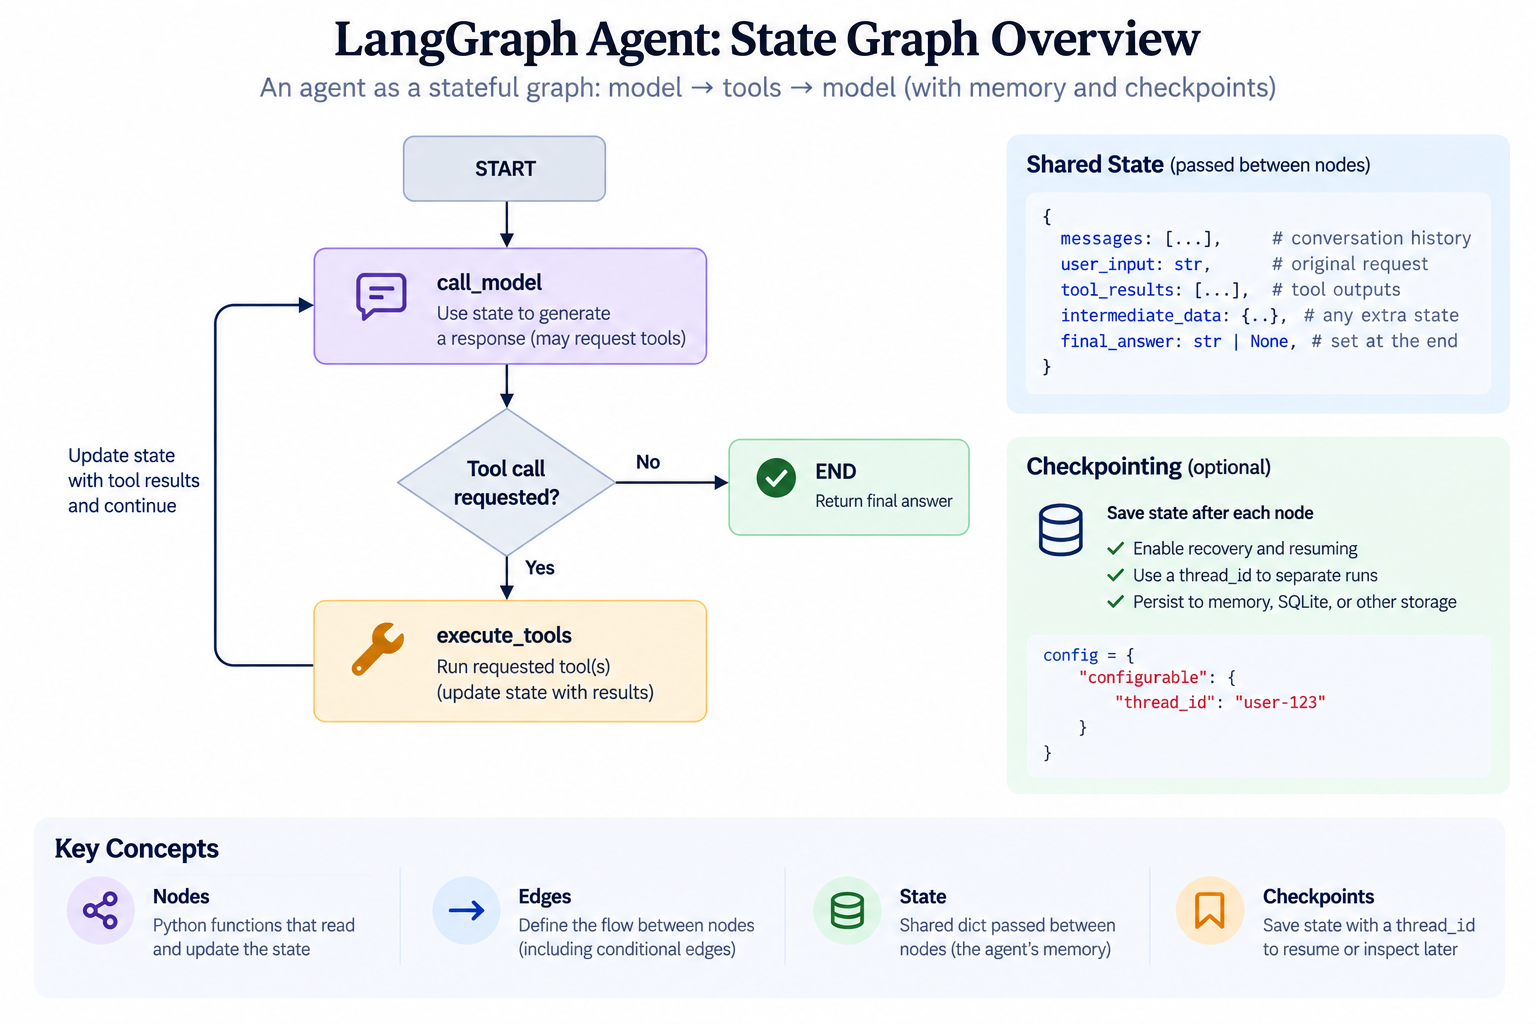

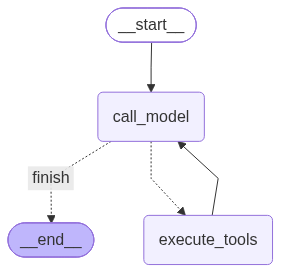

In [20]:
from IPython.display import Image, display

agent_builder = StateGraph(AgentGraphState)

agent_builder.add_node("call_model", call_model_node)
agent_builder.add_node("execute_tools", execute_tools_node)

agent_builder.add_edge(START, "call_model")

agent_builder.add_conditional_edges(
    "call_model",
    route_after_model,
    {
        "execute_tools": "execute_tools",
        "finish": END,
    },
)

agent_builder.add_edge("execute_tools", "call_model")

checkpointer = InMemorySaver()
agent_graph = agent_builder.compile(checkpointer=checkpointer)

# Display the graph as an image
display(
    Image(
        agent_graph.get_graph().draw_mermaid_png()
    )
)

`InMemorySaver` is suitable for learning and testing. Its checkpoints disappear with the Python process and should not be treated as durable production storage.

## 11. Invoke the stateful graph

A checkpointer requires a thread identifier. Runs using the same thread ID belong to the same checkpoint lineage, while different IDs isolate their state histories.

In [16]:
initial_state: AgentGraphState = {
    "user_message": (
        "According to the local notes, what is a LangGraph node? "
        "Then calculate 16 multiplied by 7."
    ),
    "interaction_id": None,
    "pending_calls": [],
    "function_results": [],
    "answer": None,
    "status": "running",
    "model_turns": 0,
    "max_model_turns": 6,
    "trace": [],
}

graph_config = {
    "configurable": {
        "thread_id": "tutorial-thread-001",
    }
}

final_state = agent_graph.invoke(
    initial_state,
    config=graph_config,
)

print("Status:", final_state["status"])
print("Answer:", final_state["answer"])
print("Model turns:", final_state["model_turns"])

Status: completed
Answer: According to the local notes, a **LangGraph node** reads graph state, performs work, and returns a partial update.

For the calculation, **16 multiplied by 7** is **112**.
Model turns: 2


In [17]:
print("Execution trace:")
for index, event in enumerate(final_state["trace"], start=1):
    print(f"{index:02d}. {event}")

Execution trace:
01. {'event': 'model_response', 'turn': 1, 'interaction_id': 'v1_ChdpbS0zYXNmOUc3QzZqckVQbk1pQTBRbxIXaW0tM2FzZjlHN0M2anJFUG5NaUEwUW8', 'step_types': ['thought', 'function_call', 'function_call'], 'function_call_count': 2}
02. {'event': 'tool_observation', 'call_id': 'call_371521', 'name': 'search_course_notes', 'arguments': {'query': 'LangGraph node'}, 'observation': {'success': True, 'result': [{'topic': 'node', 'text': 'A node reads graph state, performs work, and returns a partial update.'}, {'topic': 'langgraph', 'text': 'LangGraph represents stateful workflows with nodes, edges, conditional routing, and optional checkpointing.'}]}}
03. {'event': 'tool_observation', 'call_id': 'call_371522', 'name': 'multiply', 'arguments': {'first_number': 16, 'second_number': 7}, 'observation': {'success': True, 'result': 112.0}}
04. {'event': 'model_response', 'turn': 2, 'interaction_id': 'v1_ChdpbS0zYXNmOUc3QzZqckVQbk1pQTBRbxIXa0ctM2F1ZUlMYVdwLThZUGk5YnQwQTQ', 'step_types': ['t

## 12. Inspect the saved checkpoint

The checkpointer stores graph state snapshots under the configured thread. `get_state` returns the latest snapshot without rerunning the graph.

In [18]:
snapshot = agent_graph.get_state(graph_config)

print("Next nodes:", snapshot.next)
print("Saved status:", snapshot.values["status"])
print("Saved answer:", snapshot.values["answer"])

Next nodes: ()
Saved status: completed
Saved answer: According to the local notes, a **LangGraph node** reads graph state, performs work, and returns a partial update.

For the calculation, **16 multiplied by 7** is **112**.


A checkpoint is more than chat history. It captures the graph's state at a point in execution and enables patterns such as inspection, resumption, replay, and human approval. Durable applications should use a persistent checkpointer designed for their deployment environment.

## 13. Graph versus loop

The graph did not create new agent intelligence. It reorganized the control flow we previously wrote by hand.

| Plain loop | LangGraph equivalent |
|---|---|
| Local variables | Typed graph state |
| Function body sections | Nodes |
| `if` and `continue` | Conditional and cyclic edges |
| Returned result | Terminal graph state |
| Manual state persistence | Checkpointer |

A plain loop remains appropriate for small linear agents. LangGraph becomes useful when the system needs visible branching, resumability, interrupts, subgraphs, or several independently testable stages.

## 14. Exercise: add a validation node

Insert a `validate_input` node between `START` and `call_model`. It should:

- reject an empty or whitespace-only `user_message`;
- set `status` to `failed` and append a trace event when invalid;
- otherwise leave the run active; and
- route valid input to `call_model` and invalid input to `END`.

Rebuild the graph after adding the node, then test both an empty request and a normal request.

In [ ]:
# Define validate_input_node and its routing function here.
# Then create a new graph builder containing the validation step.

<details>
<summary><strong>Suggested validation node</strong></summary>

```python
def validate_input_node(state: AgentGraphState) -> dict[str, Any]:
    if state["user_message"].strip():
        return {"status": "running"}

    return {
        "status": "failed",
        "trace": state["trace"] + [
            {"event": "failure", "reason": "empty_user_message"}
        ],
    }


def route_after_validation(
    state: AgentGraphState,
) -> Literal["call_model", "finish"]:
    return "call_model" if state["status"] == "running" else "finish"
```

Add `validate_input` as a node, connect `START` to it, and attach a conditional edge mapping `call_model` to the model node and `finish` to `END`.

</details>

## Notebook summary

We learned LangGraph through a deterministic counter before rebuilding the Gemini agent as a state graph. The final graph separates model calls and tool execution into nodes, uses conditional routing to continue or stop, stores an explicit trace, enforces a model-turn limit, and saves snapshots with an in-memory checkpointer.

The next notebook will build Agentic RAG. Retrieval will become one optional tool rather than an unconditional first step, and we will examine when that flexibility improves the system and when it introduces additional failure modes.

### References

- [LangGraph Graph API](https://docs.langchain.com/oss/python/langgraph/graph-api)
- [LangGraph overview](https://docs.langchain.com/oss/python/langgraph/overview)
- [Gemini function calling](https://ai.google.dev/gemini-api/docs/function-calling)